EXERCISE 3

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import math

d)Solve ODE system

Initial condition

In [2]:
S0= 1 #mol/l
E0= 0.1 #mol/l
P0 = 0 #mol/l

k1b = 10 #/s
k2f = 22 #/s
Kms = 210e-6 #mol/l
Kmp = 97e-6 #mol/l

k1f = (k1b + k2f)/ Kms #l/(mol*s)
k2b = (k1b + k2f)/ Kmp #l/(mol*s)

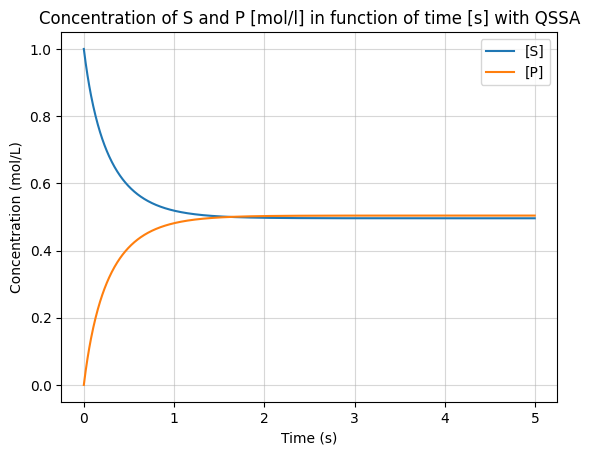

In [3]:
def balance_equation(variables, t):
    S, P = variables

    ES = E0 * (k1f * S + k2b * P)/(k1f * S + k1b + k2f + k2b * P)
    E = E0 -ES

    dSdt = -k1f * E * S + k1b * ES
    dPdt = k2f * ES  -k2b * E * P

    return dSdt, dPdt

initial_conditions = [S0, P0]
t = np.arange(start=0, stop=5, step=0.005)

results = odeint(balance_equation, initial_conditions, t)
S, P = results.T

plt.plot(t, S, t, P)
plt.grid(True, which='both', linestyle='-', alpha=0.5)
plt.title('Concentration of S and P [mol/l] in function of time [s] with QSSA')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.legend(['[S]', '[P]'])
plt.show()

Comment: The reaction proceeds in the forward direction S→P. The concentration of S decreases whilst the concentration of P increases. The reaction rapidly reaches equilibrium before all the substrate has been consumed. The system is in a steady state.

e)

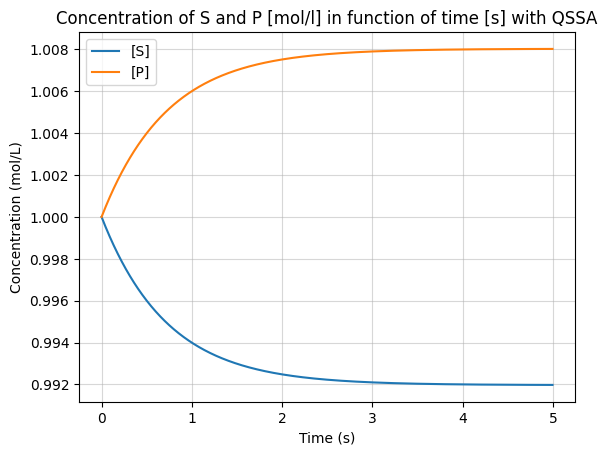

In [4]:
P02 = 1 #mol/l

initial_conditions_e = [S0, P02]

results_e = odeint(balance_equation, initial_conditions_e, t)
S_e, P_e = results_e.T

plt.plot(t, S_e, t, P_e)
plt.title('Concentration of S and P [mol/l] in function of time [s] with QSSA')
plt.grid(True, which='both', linestyle='-', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.legend(['[S]', '[P]'])
plt.show()

Comment: Here, the two curves are almost identical (note the units). This means that the initial concentrations were already very close to the equilibrium concentrations. Keq is approximately 1 ((k1f*k2f)/(k1bk2b) = 1.016) and [P]/[S] = 1, so this makes sense. 

In Project 1, the standard irreversible Michaelis-Menten equation was used. This equation depends solely on the concentration of S. However, in this problem, the reaction rate equation is more complex. As shown in Exercise c, there is a [P] in both the numerator and the denominator. The -[P] in the numerator directly subtracts from the rate, whilst the [P] in the denominator will decrease the rate if the concentration of P increases. 

For the model to be similar to Project 1, k2b must be set to 0. Consequently, [P] will no longer influence the reaction rate. 

f)

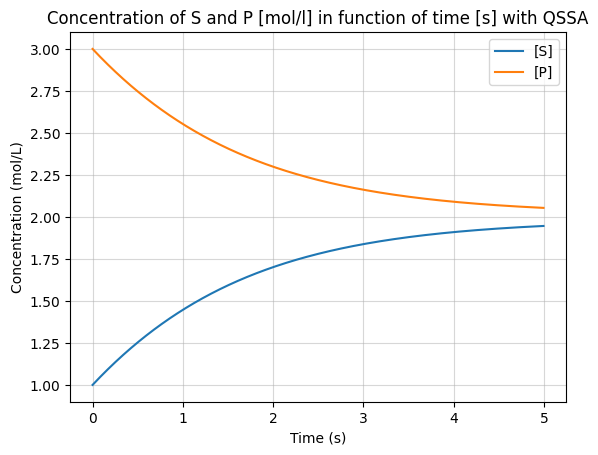

In [5]:
P03 = 3 #mol/l

initial_conditions_f = [S0, P03]

results_f = odeint(balance_equation, initial_conditions_f, t)
S_f, P_f = results_f.T

plt.plot(t, S_f, t, P_f)
plt.title('Concentration of S and P [mol/l] in function of time [s] with QSSA')
plt.grid(True, which='both', linestyle='-', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.legend(['[S]', '[P]'])
plt.show()

Comment: P decreases whilst S increases over time. This is the reverse reaction. 
The mass-action ratio is defined as Q = [P]/[S]. Here, it is equal to 3.
The equilibrium constant is defined by Keq = (k1f*k2f)/(k1b/k2b). As calculated in Exercise e, it is 1.016.
Here, Q > Keq, so there is an excess of product. According to Le Chatelier’s principle, the system will seek to reach equilibrium.